In [5]:
!pip install torch-summary
!pip install torchmetrics

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea
import os
from tqdm.notebook import tqdm
import torch
from torchsummary import summary
import torchmetrics

sea.set_style('whitegrid')
np.__version__

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [7]:
!pip install kagglehub

import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")
print("Path to dataset files:", path)

# Construct the full path to the 'dataset' directory within the downloaded content
# Assuming the 'dataset' subdirectory contains the actual images, similar to the original path.
DATASET_PATH = os.path.join(path, 'dataset')

print("Contents of base path:", os.listdir(path))
print("Contents of dataset path:", os.listdir(DATASET_PATH))

Path to dataset files: C:\Users\u\.cache\kagglehub\datasets\gunavenkatdoddi\eye-diseases-classification\versions\1
Contents of base path: ['dataset']
Contents of dataset path: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [8]:
from tqdm.std import tqdm
PATH = DATASET_PATH # Use the dynamically determined path
label2id = {}
for i, label in enumerate(sorted(os.listdir(PATH))):
    label2id[label] = i

id2label = {key : value for (value, key) in label2id.items()}

filenames, outcome = [], []

for label in tqdm(os.listdir(PATH)):
    for img in os.listdir(os.path.join(PATH, label)):
        filenames.append(os.path.join(PATH, label, img))
        outcome.append(label2id[label])


df = pd.DataFrame({
    "filename" : filenames,
    "outcome" : outcome
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

100%|██████████| 4/4 [00:00<00:00, 454.13it/s]


,filename,outcome
0,C:\Users\u\.cache\kagglehub\datasets\gunavenka...,0
1,C:\Users\u\.cache\kagglehub\datasets\gunavenka...,2
2,C:\Users\u\.cache\kagglehub\datasets\gunavenka...,2
3,C:\Users\u\.cache\kagglehub\datasets\gunavenka...,1
4,C:\Users\u\.cache\kagglehub\datasets\gunavenka...,2


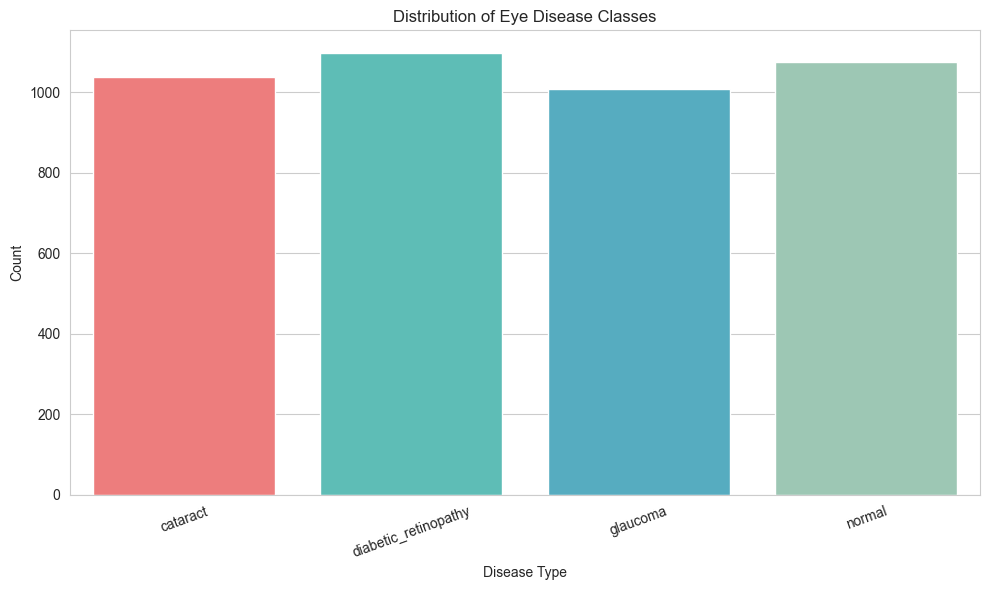

In [9]:
plt.figure(figsize=(10, 6))
# Create a custom color palette with distinct colors for each class
# Cataract will be a distinct orange/red color
n_classes = len(id2label)
color_map = {}
for i in range(n_classes):
    label_lower = id2label[i].lower()
    if 'cataract' in label_lower:
        color_map[i] = '#FF6B6B'  # Red/Orange for cataract
    elif 'diabetic' in label_lower:
        color_map[i] = '#4ECDC4'  # Teal for diabetic retinopathy
    elif 'glaucoma' in label_lower:
        color_map[i] = '#45B7D1'  # Blue for glaucoma
    else:
        color_map[i] = '#96CEB4'  # Green for normal/other

# Create color list in order
colors = [color_map[i] for i in range(n_classes)]
sea.countplot(x='outcome', data=df, hue='outcome', palette=colors, legend=False)
plt.title('Distribution of Eye Disease Classes')
plt.xlabel('Disease Type')
plt.ylabel('Count')
plt.xticks(
    ticks=range(len(id2label)),
    labels=[id2label[i] for i in range(len(id2label))],
    rotation=20
)
plt.tight_layout()
plt.show()


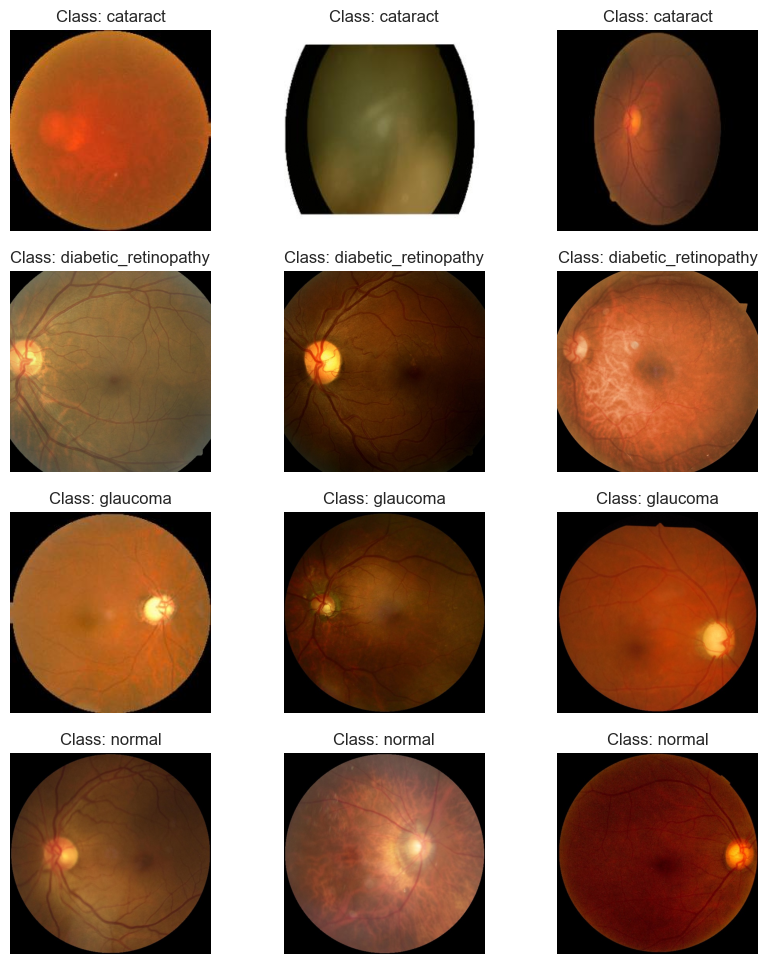

In [10]:
def load_image(path):
    img = plt.imread(path)
    img = (img - img.min())/img.max()
    return img

counter = 0

plt.figure(figsize = (10, 12))

for i in range(4):
    for path in df[df['outcome'] == i].sample(n = 3)['filename']:
        plt.subplot(4, 3, counter + 1)
        img = load_image(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title('Class:' + " " + id2label[i])
        counter += 1

plt.show()

In [11]:
from PIL import Image
import numpy as np
!pip install opencv-python
import cv2

In [12]:
class ApplyCLAHE(object):
    def __init__(self, clip=2.0, grid=(8,8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)

    def __call__(self, img):
        img = np.array(img)
        if len(img.shape) == 3:
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            l = self.clahe.apply(l)
            lab = cv2.merge((l,a,b))
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

In [13]:
import torchvision.transforms as transforms
import torchvision.transforms as T

train_transform = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(0.5),
    T.RandomAffine(degrees=8, translate=(0.03,0.03), scale=(0.95,1.05)),
    T.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05),
    T.RandomApply([ApplyCLAHE()], p=0.15),
    T.ToTensor(),
    T.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225)),
])



In [14]:
val_transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

In [15]:
from torch.utils.data import Dataset

class EyeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        path = self.df.iloc[index, 0]
        label = self.df.iloc[index, 1]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(label, dtype=torch.long)
        return img, label

In [16]:
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim.lr_scheduler import StepLR

In [ ]:
# resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-3)
# resnet_scheduler = StepLR(resnet_optimizer, step_size=5, gamma=0.1)

In [ ]:
#


In [17]:
from transformers import AutoImageProcessor, SwinForImageClassification, get_scheduler
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

In [18]:
import numpy as np

def train_epoch(model, device, dataloader, optimizer, scheduler, loss_fn):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    lrs = []

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=images)
        logits = outputs.logits

        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # LR log (scheduler her batch'te ilerliyor)
        lrs.append(optimizer.param_groups[0]["lr"])

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    avg_lr = float(np.mean(lrs)) if len(lrs) else optimizer.param_groups[0]["lr"]

    return avg_loss, accuracy, avg_lr

In [19]:
import torch
import numpy as np

@torch.no_grad()
def eval_epoch(model, device, dataloader, loss_fn, return_outputs=True):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images)
        logits = outputs.logits
        loss = loss_fn(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        if return_outputs:
            all_labels.append(labels.detach().cpu())
            all_preds.append(preds.detach().cpu())
            all_probs.append(probs.detach().cpu())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    if return_outputs:
        y_true = torch.cat(all_labels).numpy()
        y_pred = torch.cat(all_preds).numpy()
        y_prob = torch.cat(all_probs).numpy()
        return avg_loss, accuracy, y_true, y_pred, y_prob

    return avg_loss, accuracy

In [25]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader

batch_size = 32
num_epochs = 15
n_splits = 5
patience = 4 

dev_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["outcome"],
    random_state=42
)

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
indices = np.arange(len(dev_df))

fold_histories = []
fold_summaries = []
cv_val_accs = []
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(skf.split(indices, dev_df["outcome"])):
    print(f"\nFold {fold + 1}/{n_splits}")

    train_df = dev_df.iloc[train_idx].reset_index(drop=True)
    val_df = dev_df.iloc[val_idx].reset_index(drop=True)

    train_dataset = EyeDataset(train_df, transform=train_transform)
    val_dataset   = EyeDataset(val_df, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    swin_model = SwinForImageClassification.from_pretrained(
        "microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(label2id),
        label2id=label2id,
        id2label=id2label,
        ignore_mismatched_sizes=True,
    ).to(device)

    decay, no_decay = [], []
    for n, p in swin_model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or n.endswith(".bias") or "LayerNorm.weight" in n:
            no_decay.append(p)
        else:
            decay.append(p)

    swin_optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": 0.05},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=3e-5
    )
   

    training_steps = num_epochs * len(train_loader)
    warmup_steps = int(0.1 * training_steps)

    swin_scheduler = get_scheduler(
    name="cosine",
    optimizer=swin_optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=training_steps
)

    best_val_loss = float("inf")
    best_val_acc = 0.0
    epochs_without_improvement = 0

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_outputs = None

    for epoch in range(num_epochs):
        print(f"\nFold {fold + 1} - Epoch {epoch + 1}/{num_epochs}")

        train_loss, train_acc, avg_lr = train_epoch(
            swin_model, device, train_loader, swin_optimizer, swin_scheduler, loss_fn
        )

        val_loss, val_acc, y_true, y_pred, y_prob = eval_epoch(
            swin_model, device, val_loader, loss_fn, return_outputs=True
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(avg_lr)

        print(
            f"[Fold {fold + 1}] Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | LR: {avg_lr:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_without_improvement = 0
            best_outputs = (y_true, y_pred, y_prob)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(
                    f"Early stopping on fold {fold + 1} at epoch {epoch + 1} "
                    f"(no val_loss improvement for {patience} epochs)."
                )
                break

    print(
        f"Best validation for fold {fold + 1}: "
        f"Val Loss={best_val_loss:.4f}, Val Acc={best_val_acc:.4f}"
    )

    fold_histories.append(history)
    fold_summaries.append({
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "best_outputs": best_outputs
    })
    cv_val_accs.append(best_val_acc)
    cv_val_losses.append(best_val_loss)



Fold 1/5


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Fold 1 - Epoch 1/15


100%|██████████| 22/22 [00:04<00:00,  4.99it/s]


[Fold 1] Train Loss: 1.1024 | Train Acc: 0.5504 | Val Loss: 0.7531 | Val Acc: 0.7763 | LR: 1.02e-05

Fold 1 - Epoch 2/15


...

[Fold 5] Train Loss: 0.4062 | Train Acc: 0.9748 | Val Loss: 0.4945 | Val Acc: 0.9199 | LR: 2.48e-06

Fold 5 - Epoch 14/15


100%|██████████| 22/22 [00:03<00:00,  5.95it/s]


[Fold 5] Train Loss: 0.4044 | Train Acc: 0.9763 | Val Loss: 0.4932 | Val Acc: 0.9199 | LR: 9.29e-07

Fold 5 - Epoch 15/15


100%|██████████| 22/22 [00:03<00:00,  5.87it/s]

[Fold 5] Train Loss: 0.4005 | Train Acc: 0.9800 | Val Loss: 0.4933 | Val Acc: 0.9199 | LR: 1.33e-07
Best validation for fold 5: Val Loss=0.4904, Val Acc=0.9184


In [26]:
import copy
from sklearn.metrics import f1_score

print("K-FOLD CROSS-VALIDATION RESULTS")
print(f"Mean Val Accuracy: {np.mean(cv_val_accs):.4f} (+/- {np.std(cv_val_accs):.4f})")
print(f"Mean Val Loss: {np.mean(cv_val_losses):.4f} (+/- {np.std(cv_val_losses):.4f})")

final_train_df, final_val_df = train_test_split(
    dev_df, test_size=0.1, stratify=dev_df["outcome"], random_state=42
)

final_train_loader = DataLoader(EyeDataset(final_train_df, train_transform), batch_size=32, shuffle=True)
final_val_loader   = DataLoader(EyeDataset(final_val_df,   val_transform),   batch_size=32, shuffle=False)

# Create final model
final_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
).to(device)

best_state = None
best_macro_f1 = -1.0
bad = 0

decay, no_decay = [], []
for n, p in final_model.named_parameters():
    if not p.requires_grad:
        continue
    if p.ndim == 1 or n.endswith(".bias") or "LayerNorm.weight" in n:
        no_decay.append(p)
    else:
        decay.append(p)

final_optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": 0.05},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=3e-5
)

final_training_steps = num_epochs * len(final_train_loader)
final_warmup_steps = int(0.1 * final_training_steps)

final_scheduler = get_scheduler(
    name="cosine",
    optimizer=final_optimizer,
    num_warmup_steps=final_warmup_steps,
    num_training_steps=final_training_steps,
)

final_history = {"train_loss": [], "train_acc": [], "lr": []}

for epoch in range(num_epochs):
    print(f"Final Model - Epoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc, avg_lr = train_epoch(
        final_model, device, final_train_loader, final_optimizer, final_scheduler, loss_fn
    )

    val_loss, val_acc, y_true, y_pred, y_prob = eval_epoch(
        final_model, device, final_val_loader, loss_fn, return_outputs=True
    )

    final_history["train_loss"].append(train_loss)
    final_history["train_acc"].append(train_acc)
    final_history["lr"].append(avg_lr)

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | LR: {avg_lr:.2e}"
    )

    macro_f1 = f1_score(y_true, y_pred, average="macro")

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_state = copy.deepcopy(final_model.state_dict())
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping final model.")
            break

final_model.load_state_dict(best_state)
print("Best final-val macro F1:", best_macro_f1)

print("STEP 3: FINAL EVALUATION (on Held-Out Test Set)")

K-FOLD CROSS-VALIDATION RESULTS
Mean Val Accuracy: 0.9377 (+/- 0.0119)
Mean Val Loss: 0.4759 (+/- 0.0152)


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Final Model - Epoch 1/15


100%|██████████| 11/11 [00:01<00:00,  6.33it/s]


Train Loss: 1.0757 | Train Acc: 0.5839 | LR: 1.01e-05
Final Model - Epoch 2/15


...

Train Loss: 0.4152 | Train Acc: 0.9700 | LR: 2.48e-06
Final Model - Epoch 14/15


100%|██████████| 11/11 [00:01<00:00,  6.38it/s]


Train Loss: 0.4112 | Train Acc: 0.9736 | LR: 9.29e-07
Final Model - Epoch 15/15


100%|██████████| 11/11 [00:01<00:00,  6.30it/s]

Train Loss: 0.4099 | Train Acc: 0.9717 | LR: 1.33e-07
Best final-val macro F1: 0.93765292521684
STEP 3: FINAL EVALUATION (on Held-Out Test Set)


In [27]:
test_dataset = EyeDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

test_loss, test_acc, y_true, y_pred, y_prob = eval_epoch(
    final_model, device, test_loader, loss_fn, return_outputs=True
)

print(f"Final Test Loss: {test_loss:.4f} | Final Test Accuracy: {test_acc:.4f}")


100%|██████████| 27/27 [00:05<00:00,  5.36it/s]

Final Test Loss: 0.4654 | Final Test Accuracy: 0.9431


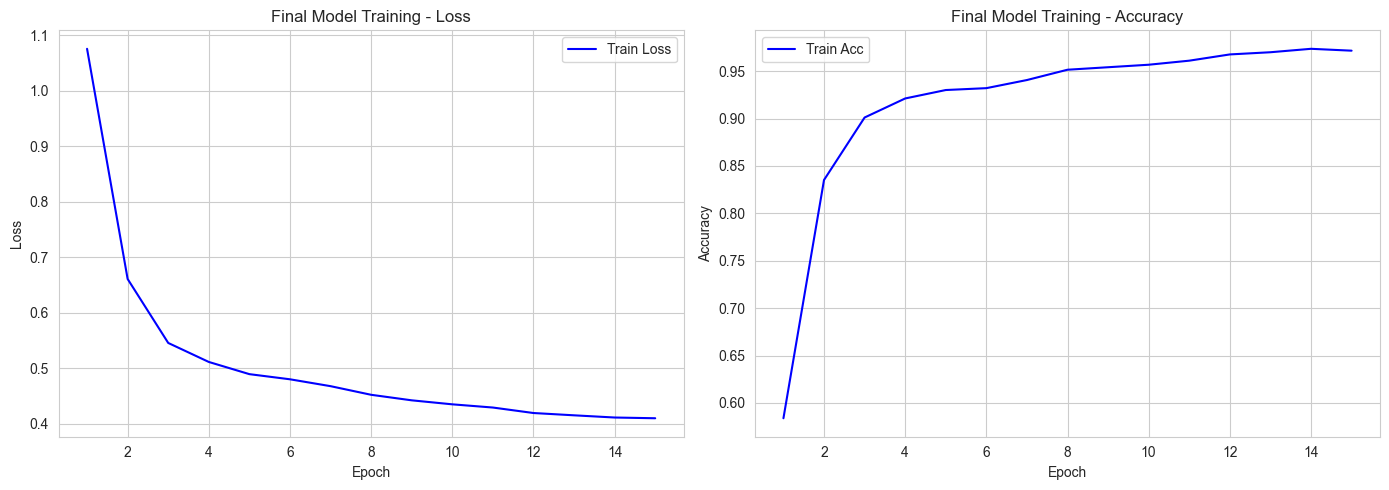

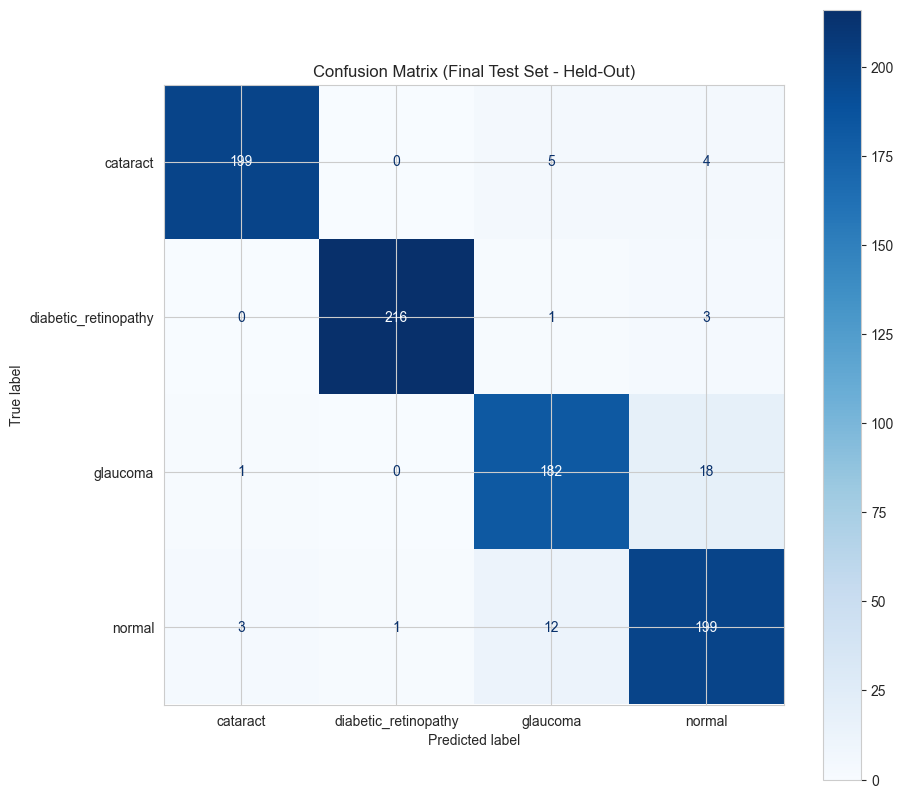

FINAL CLASSIFICATION REPORT (Held-Out Test Set)
                      precision    recall  f1-score   support

            cataract     0.9803    0.9567    0.9684       208
diabetic_retinopathy     0.9954    0.9818    0.9886       220
            glaucoma     0.9100    0.9055    0.9077       201
              normal     0.8884    0.9256    0.9066       215

            accuracy                         0.9431       844
           macro avg     0.9435    0.9424    0.9428       844
        weighted avg     0.9441    0.9431    0.9435       844


Summary:
  K-Fold CV Mean Val Accuracy: 0.9377 (+/- 0.0119)
  Final Test Accuracy: 0.9431


In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Training curves (Final Model)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(final_history["train_loss"]) + 1)
axes[0].plot(epochs, final_history["train_loss"], 'b-', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Final Model Training - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, final_history["train_acc"], 'b-', label='Train Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Final Model Training - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix (Final Test Set)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[id2label[i] for i in range(len(id2label))]
)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix (Final Test Set - Held-Out)")
plt.show()

# Classification Report (Final Test Set)
print("FINAL CLASSIFICATION REPORT (Held-Out Test Set)")
print(classification_report(
    y_true,
    y_pred,
    target_names=[id2label[i] for i in range(len(id2label))],
    digits=4
))
print(f"\nSummary:")
print(f"  K-Fold CV Mean Val Accuracy: {np.mean(cv_val_accs):.4f} (+/- {np.std(cv_val_accs):.4f})")
print(f"  Final Test Accuracy: {test_acc:.4f}")

In [24]:
import torch
import transformers
from transformers import SwinForImageClassification

# Check if final_model exists, if not recreate from best_state
if 'final_model' not in globals() or final_model is None:
    if 'best_state' in globals() and best_state is not None:
        print("⚠️ final_model not found. Recreating from best_state...")
        final_model = SwinForImageClassification.from_pretrained(
            "microsoft/swin-tiny-patch4-window7-224",
            num_labels=len(label2id),
            label2id=label2id,
            id2label=id2label,
            ignore_mismatched_sizes=True,
        ).to(device)
        final_model.load_state_dict(best_state)
        print("✅ Model recreated from best_state")
    else:
        raise NameError(
            "❌ Neither 'final_model' nor 'best_state' is defined. "
            "Please run Cell 18 (final model training) first!"
        )

# Save the final model
torch.save({
    'model_state_dict': final_model.state_dict(),
    'label2id': label2id,
    'id2label': id2label,
    'model_name': 'microsoft/swin-tiny-patch4-window7-224',
    'transformers_version': transformers.__version__,
}, 'swin_tiny_kfold_model.pt')

print("✅ Model saved successfully to 'swin_tiny_kfold_model.pt'")

✅ Model saved successfully to 'swin_tiny_kfold_model.pt'
